In [8]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation and analysis
import numpy as np
import pandas as pd

# Multi-dimensional arrays and datasets (e.g., NetCDF, Zarr)
import xarray as xr

# Geospatial raster data handling with CRS support
import rioxarray as rxr

# Raster operations and spatial windowing
import rasterio
from rasterio.windows import Window

# Feature preprocessing and data splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.spatial import cKDTree

from lightgbm import LGBMRegressor
import optuna
import lightgbm as lgb

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold
import numpy as np
import math

# Planetary Computer tools for STAC API access and authentication
import pystac_client
import planetary_computer as pc
from odc.stac import stac_load
from pystac.extensions.eo import EOExtension as eo

from datetime import date
from tqdm import tqdm
import os 

In [9]:
Water_Quality_df=pd.read_csv('./data/water_quality_training_dataset.csv')
Water_Quality_df.head()

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0


In [10]:
landsat_train_features = pd.read_csv('./data/landsat_features_training.csv')
landsat_train_features.head()

,Latitude,Longitude,Sample Date,nir,green,swir16,swir22,NDMI,MNDWI
0,-28.760833,17.730278,02-01-2011,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595
1,-26.861111,28.884722,03-01-2011,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134
2,-26.450000,28.085833,03-01-2011,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805
3,-27.671111,27.236944,03-01-2011,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416
4,-27.356667,27.286389,03-01-2011,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683


In [11]:
Terraclimate_df = pd.read_csv('./data/terraclimate_features_training.csv')
Terraclimate_df.head()

,Latitude,Longitude,Sample Date,pet,ppt,aet,def,pdsi,q,soil,tmax,tmin,vpd
0,-28.760833,17.730278,02-01-2011,174.2,32.7,31.100000,143.100000,3.65,1.6,0.0,36.100000,22.689999,2.92
1,-26.861111,28.884722,03-01-2011,124.1,51.1,53.800000,70.300000,0.66,2.6,12.8,27.160000,13.219999,0.95
2,-26.450000,28.085833,03-01-2011,127.5,62.7,60.800000,66.700005,-1.16,3.1,6.8,27.519999,14.090000,1.02
3,-27.671111,27.236944,03-01-2011,129.7,84.2,83.200005,46.500000,2.84,4.2,7.2,28.869999,14.639999,1.22
4,-27.356667,27.286389,03-01-2011,129.2,78.0,77.300000,51.900000,2.65,3.9,7.8,28.670000,14.690000,1.18


In [12]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2,dataset3):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2,dataset3], axis=1)
    data = data.loc[:, ~data.columns.duplicated()]
    return data

In [13]:
# Combining ground data and final data into a single dataset.
wq_data = combine_two_datasets(Water_Quality_df, landsat_train_features, Terraclimate_df)
print(len(wq_data))
wq_data.head()

9319


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,nir,green,swir16,swir22,...,pet,ppt,aet,def,pdsi,q,soil,tmax,tmin,vpd
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,11190.0,11426.0,7687.5,7645.0,...,174.2,32.7,31.100000,143.100000,3.65,1.6,0.0,36.100000,22.689999,2.92
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,17658.5,9550.0,13746.5,10574.0,...,124.1,51.1,53.800000,70.300000,0.66,2.6,12.8,27.160000,13.219999,0.95
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,15210.0,10720.0,17974.0,14201.0,...,127.5,62.7,60.800000,66.700005,-1.16,3.1,6.8,27.519999,14.090000,1.02
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,14887.0,10943.0,13522.0,11403.0,...,129.7,84.2,83.200005,46.500000,2.84,4.2,7.2,28.869999,14.639999,1.22
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,16828.5,9502.5,12665.5,9643.0,...,129.2,78.0,77.300000,51.900000,2.65,3.9,7.8,28.670000,14.690000,1.18


In [14]:
import pandas as pd

# 1. 샘플 데이터 확인 (상위 5개)
print("--- Data Sample ---")
print(wq_data['Sample Date'].head())

# 2. 날짜 분리해서 월/일 범위 체크
# 구분자(/ 또는 -)로 나누어 첫 번째 숫자와 두 번째 숫자를 확인합니다.
date_split = wq_data['Sample Date'].str.split(r'[/|-]', expand=True)

# 첫 번째 값이 12를 초과하는 경우 (일(Day)일 확률 높음)
first_gt_12 = (date_split[0].astype(float) > 12).any()
# 두 번째 값이 12를 초과하는 경우 (일(Day)일 확률 높음)
second_gt_12 = (date_split[1].astype(float) > 12).any()

print("\n--- Format Check ---")
if first_gt_12 and not second_gt_12:
    print("결과: DD/MM/YYYY 형식일 가능성이 매우 높습니다.")
elif second_gt_12 and not first_gt_12:
    print("결과: MM/DD/YYYY 형식일 가능성이 매우 높습니다.")
elif first_gt_12 and second_gt_12:
    print("경고: 데이터 내에 형식이 혼용되어 있을 수 있습니다!")
else:
    print("결과: 모든 값이 12 이하입니다. 추가 확인(시계열 순서 등)이 필요합니다.")


--- Data Sample ---
0    02-01-2011
1    03-01-2011
2    03-01-2011
3    03-01-2011
4    03-01-2011
Name: Sample Date, dtype: object

--- Format Check ---
결과: DD/MM/YYYY 형식일 가능성이 매우 높습니다.


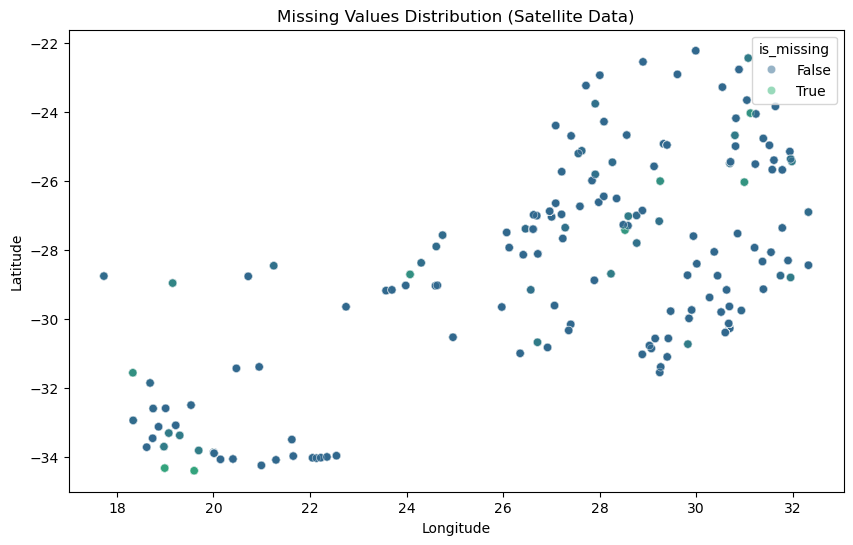

In [15]:
# 결측치 여부 컬럼 생성 (하나라도 결측치면 True)
wq_data['is_missing'] = wq_data['nir'].isna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=wq_data, x='Longitude', y='Latitude', hue='is_missing', palette='viridis', alpha=0.5)
plt.title('Missing Values Distribution (Satellite Data)')
plt.show()

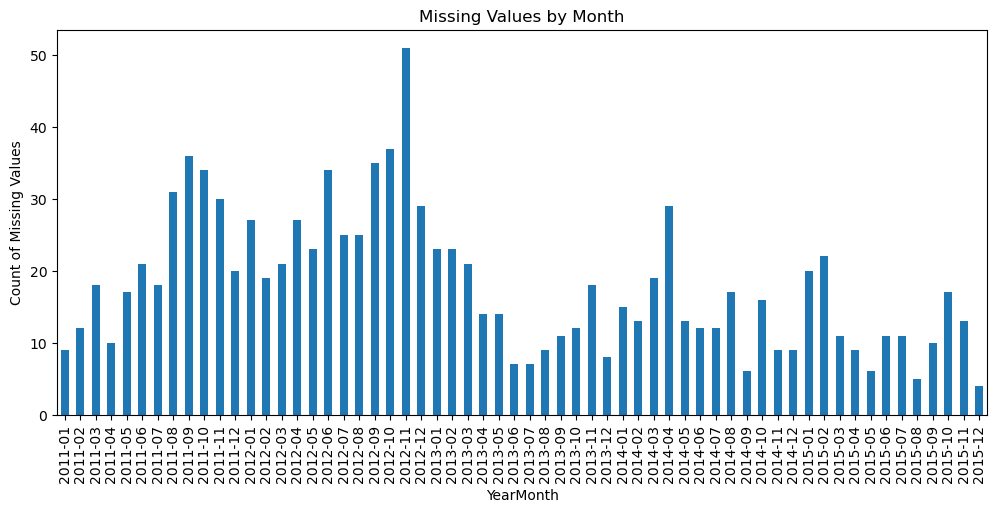

In [16]:
wq_data['Sample Date'] = pd.to_datetime(wq_data['Sample Date'], dayfirst=True)
wq_data['YearMonth'] = wq_data['Sample Date'].dt.to_period('M')

missing_by_time = wq_data.groupby('YearMonth')['nir'].apply(lambda x: x.isna().sum())
missing_by_time.plot(kind='bar', figsize=(12, 5), title='Missing Values by Month')
plt.ylabel('Count of Missing Values')
plt.show()


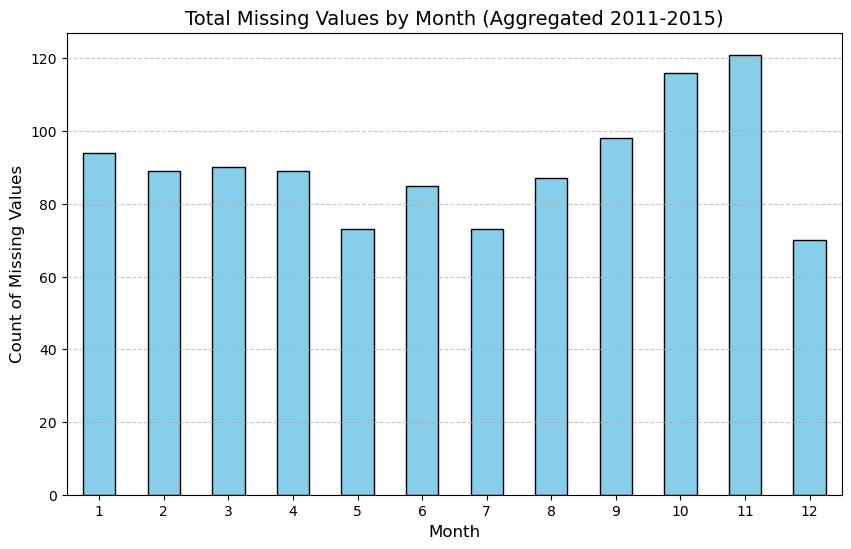

Missing Values by Month:
Month
1      94
2      89
3      90
4      89
5      73
6      85
7      73
8      87
9      98
10    116
11    121
12     70
Name: nir, dtype: int64


In [17]:
# 1. 월(Month) 정보 추출
wq_data['Month'] = wq_data['Sample Date'].dt.month

# 2. 월별 결측치 합계 계산
missing_by_month = wq_data.groupby('Month')['nir'].apply(lambda x: x.isna().sum())

# 3. 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
missing_by_month.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Missing Values by Month (Aggregated 2011-2015)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Count of Missing Values', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. 수치 확인
print("Missing Values by Month:")
print(missing_by_month)


## Filling Missing Values
<p>Can see some seasonality. Worth trying to fill missiing values by month+clusters </p>

In [18]:
dt = pd.to_datetime(wq_data['Sample Date'], dayfirst=True, errors='coerce')
wq_data['month'] = dt.dt.month
wq_data['sin_month'] = np.sin(2*np.pi*wq_data['month']/12)
wq_data['cos_month'] = np.cos(2*np.pi*wq_data['month']/12)

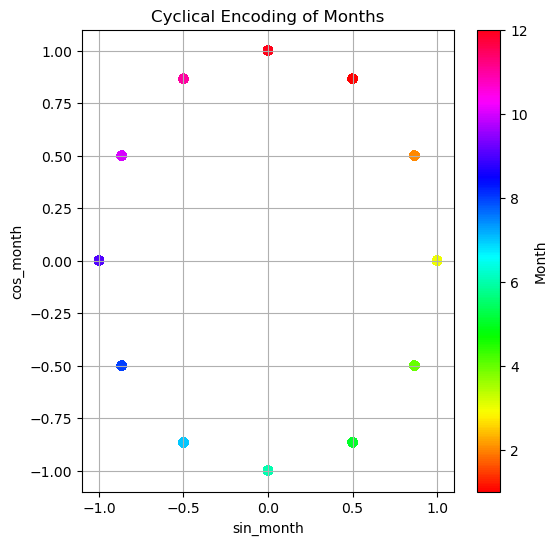

In [19]:
import matplotlib.pyplot as plt

# 데이터 시각화 (wq_data 기준)
plt.figure(figsize=(6,6))
plt.scatter(wq_data['sin_month'], wq_data['cos_month'], c=wq_data['month'], cmap='hsv')
plt.colorbar(label='Month')
plt.xlabel('sin_month')
plt.ylabel('cos_month')
plt.title('Cyclical Encoding of Months')
plt.grid(True)
plt.show()

# Right Skewed Target Features

## Worth trying log1p

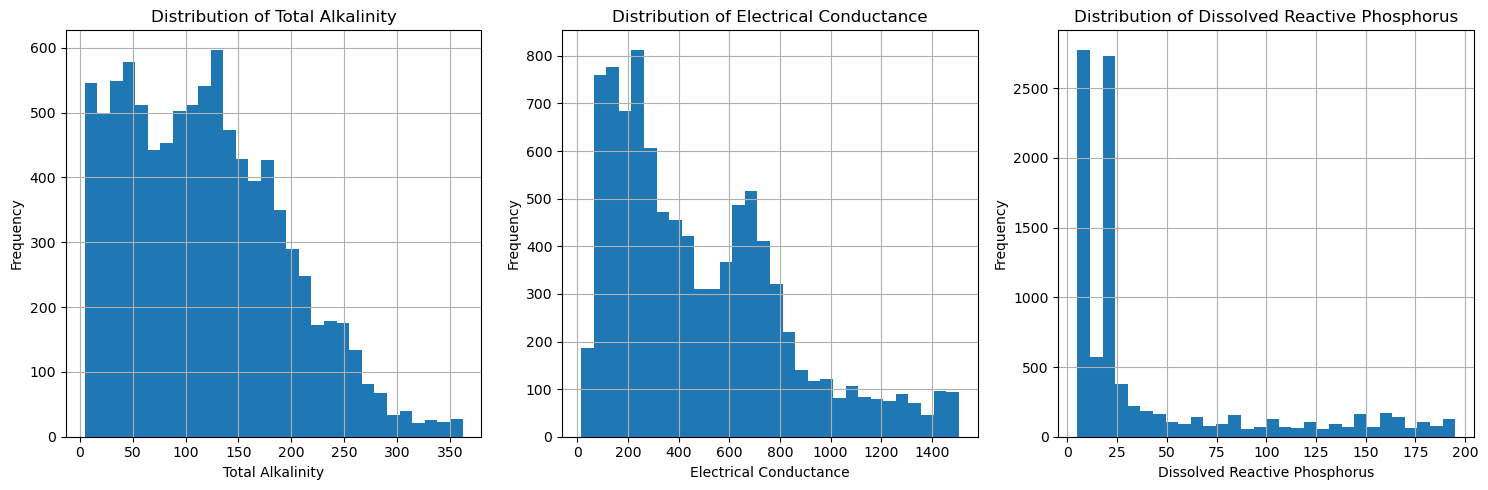

In [20]:
# target features visualization

# 1행 3열의 서브플롯 생성 (전체 크기 조절)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Total Alkalinity
Water_Quality_df['Total Alkalinity'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution of Total Alkalinity')
axes[0].set_xlabel('Total Alkalinity')
axes[0].set_ylabel('Frequency')

# 2. Electrical Conductance
Water_Quality_df['Electrical Conductance'].hist(bins=30, ax=axes[1])
axes[1].set_title('Distribution of Electrical Conductance')
axes[1].set_xlabel('Electrical Conductance')
axes[1].set_ylabel('Frequency')

# 3. Dissolved Reactive Phosphorus
Water_Quality_df['Dissolved Reactive Phosphorus'].hist(bins=30, ax=axes[2])
axes[2].set_title('Distribution of Dissolved Reactive Phosphorus')
axes[2].set_xlabel('Dissolved Reactive Phosphorus')
axes[2].set_ylabel('Frequency')

# 그래프 간 간격 자동 조정
plt.tight_layout()
plt.show()


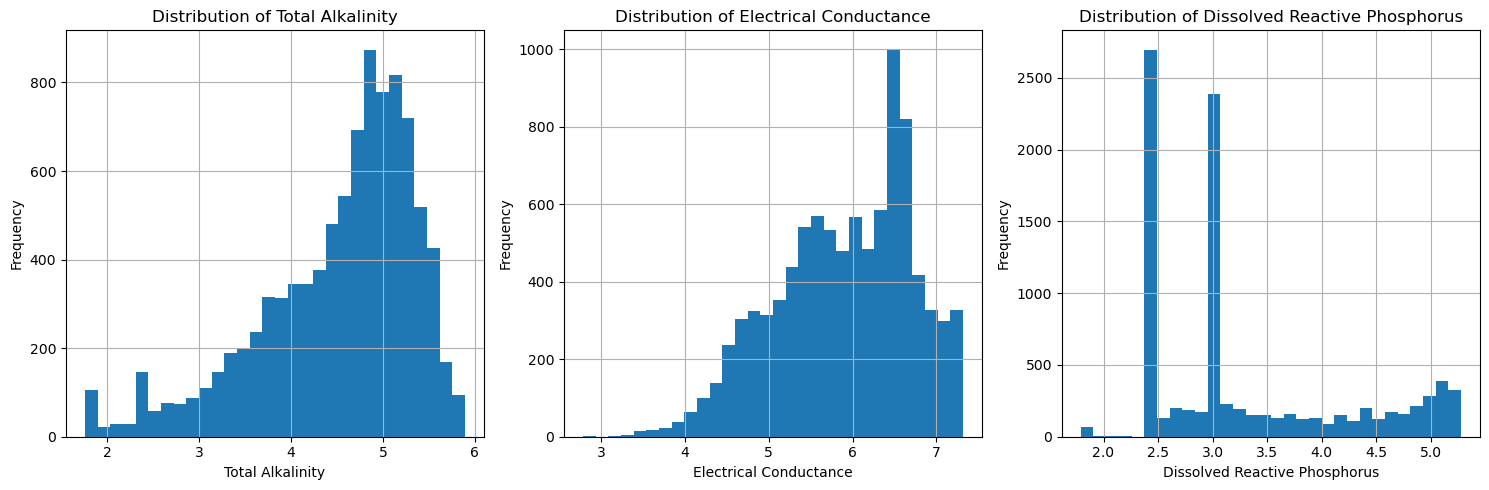

In [21]:
# target features visualization

# 1행 3열의 서브플롯 생성 (전체 크기 조절)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Total Alkalinity
np.log1p(Water_Quality_df['Total Alkalinity']).hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution of Total Alkalinity')
axes[0].set_xlabel('Total Alkalinity')
axes[0].set_ylabel('Frequency')

# 2. Electrical Conductance
np.log1p(Water_Quality_df['Electrical Conductance']).hist(bins=30, ax=axes[1])
axes[1].set_title('Distribution of Electrical Conductance')
axes[1].set_xlabel('Electrical Conductance')
axes[1].set_ylabel('Frequency')

# 3. Dissolved Reactive Phosphorus
np.log1p(Water_Quality_df['Dissolved Reactive Phosphorus']).hist(bins=30, ax=axes[2])
axes[2].set_title('Distribution of Dissolved Reactive Phosphorus')
axes[2].set_xlabel('Dissolved Reactive Phosphorus')
axes[2].set_ylabel('Frequency')

# 그래프 간 간격 자동 조정
plt.tight_layout()
plt.show()


# K-means Visualization

In [22]:
def kmeans_regions(df, lat_col="Latitude", lon_col="Longitude", n_clusters=20, random_state=42):
    """
    example return: [1 1 1 0 0 0 2 2] when there are 3 clusters and 8 samples.
    """
    km = KMeans(n_clusters=n_clusters, random_state=random_state)
    clusters = km.fit_predict(df[[lat_col, lon_col]].to_numpy())
    return clusters

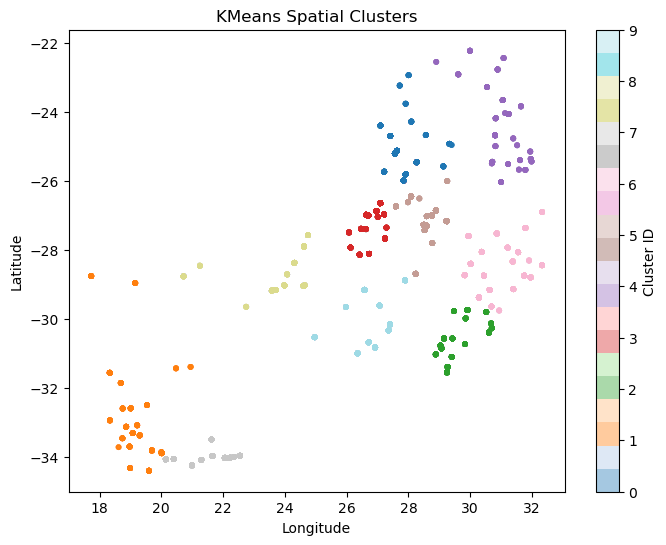

In [23]:
clusters = kmeans_regions(wq_data, n_clusters=10)

plt.figure(figsize=(8,6))
plt.scatter(
    wq_data['Longitude'],
    wq_data['Latitude'],
    c=clusters,
    cmap='tab20',
    s=10,
    alpha=0.4
)
plt.colorbar(label="Cluster ID")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KMeans Spatial Clusters")
plt.show()

In [24]:
print(len(wq_data))  # 전체 데이터
print(wq_data[['Latitude','Longitude']].drop_duplicates().shape)
pd.Series(clusters).value_counts().sort_index()

9319
(162, 2)


0    1044
1     878
2     934
3    1823
4     618
5    1168
6     958
7     557
8     702
9     637
Name: count, dtype: int64

In [25]:
num_cols = wq_data.select_dtypes(include='number').columns
cat_cols = wq_data.select_dtypes(exclude='number').columns

array([[<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'Total Alkalinity'}>,
        <Axes: title={'center': 'Electrical Conductance'}>,
        <Axes: title={'center': 'Dissolved Reactive Phosphorus'}>],
       [<Axes: title={'center': 'nir'}>,
        <Axes: title={'center': 'green'}>,
        <Axes: title={'center': 'swir16'}>,
        <Axes: title={'center': 'swir22'}>,
        <Axes: title={'center': 'NDMI'}>],
       [<Axes: title={'center': 'MNDWI'}>,
        <Axes: title={'center': 'pet'}>, <Axes: title={'center': 'ppt'}>,
        <Axes: title={'center': 'aet'}>, <Axes: title={'center': 'def'}>],
       [<Axes: title={'center': 'pdsi'}>, <Axes: title={'center': 'q'}>,
        <Axes: title={'center': 'soil'}>,
        <Axes: title={'center': 'tmax'}>,
        <Axes: title={'center': 'tmin'}>],
       [<Axes: title={'center': 'vpd'}>,
        <Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'm

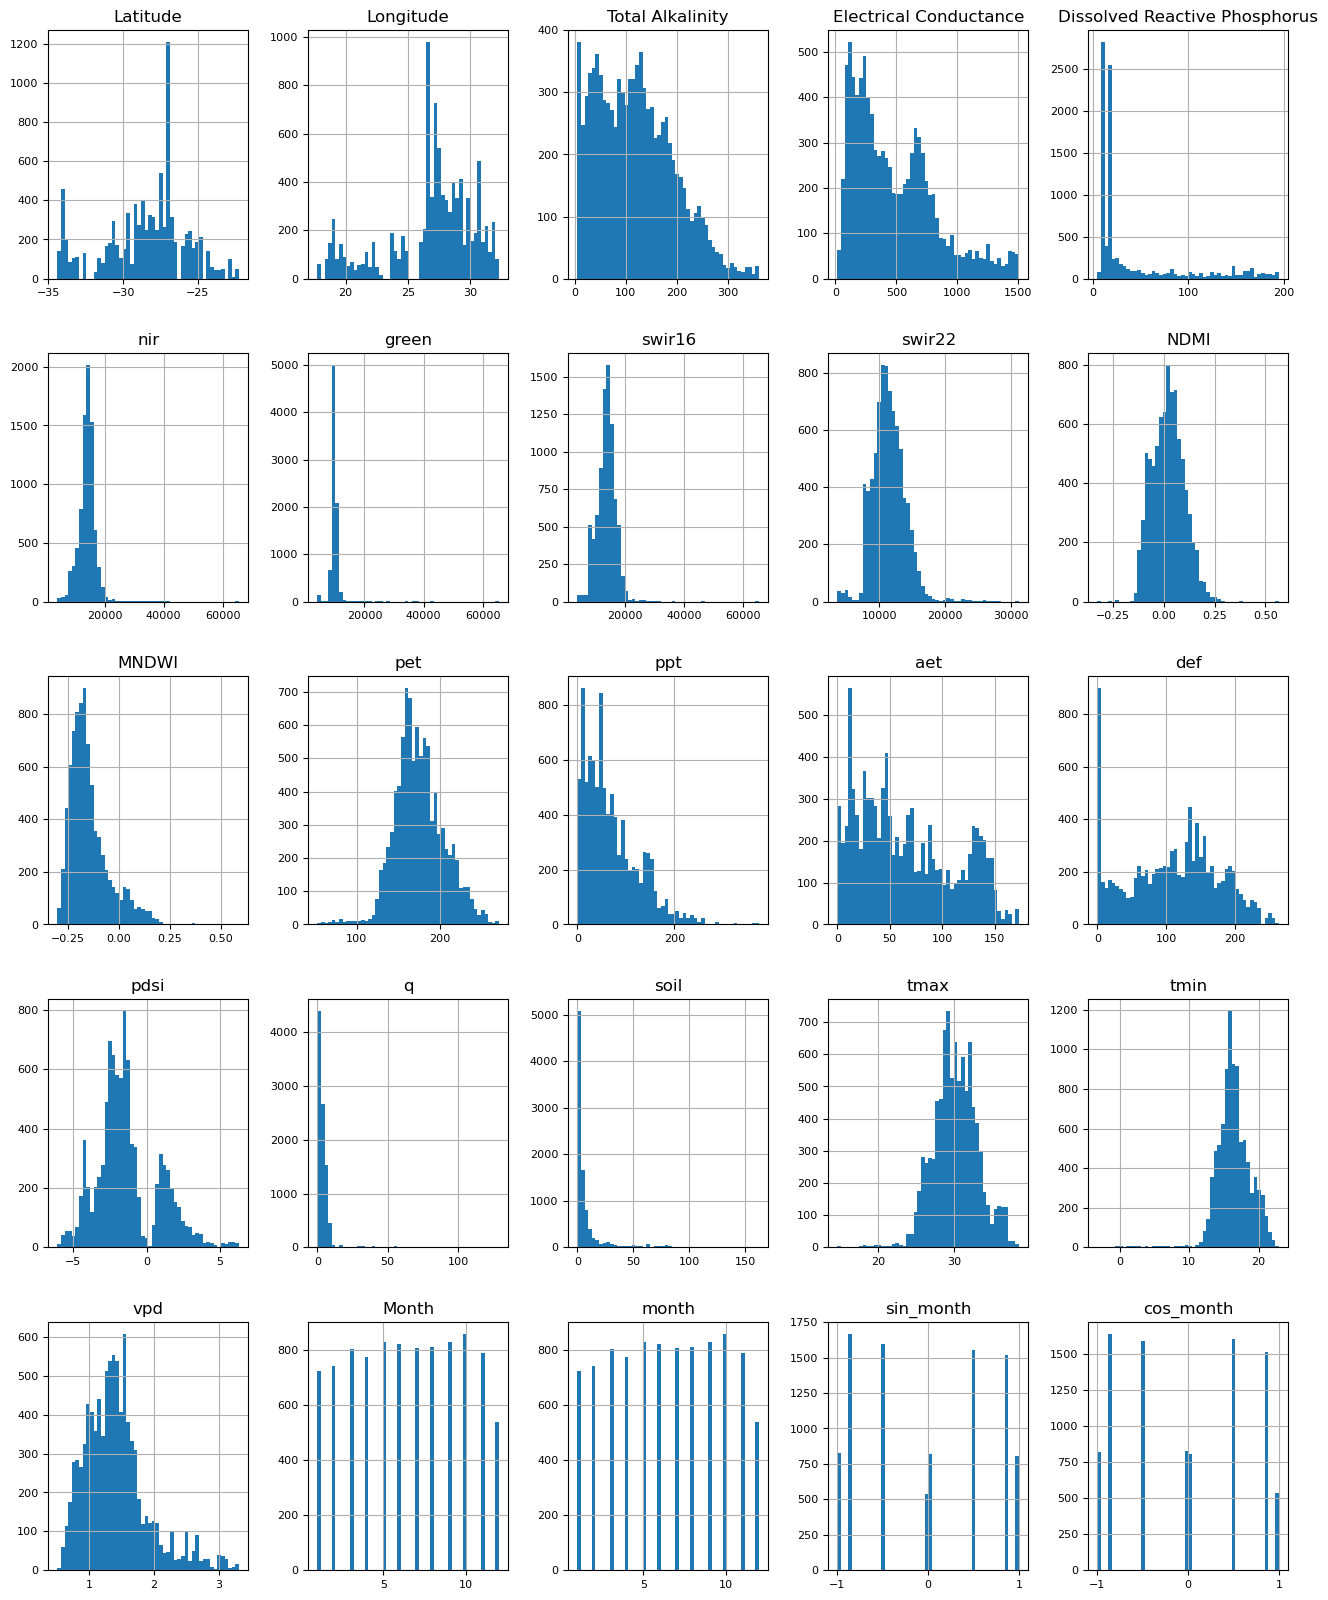

In [26]:
wq_data[num_cols].hist(bins=50, figsize=(16, 20), xlabelsize=8, ylabelsize=8)

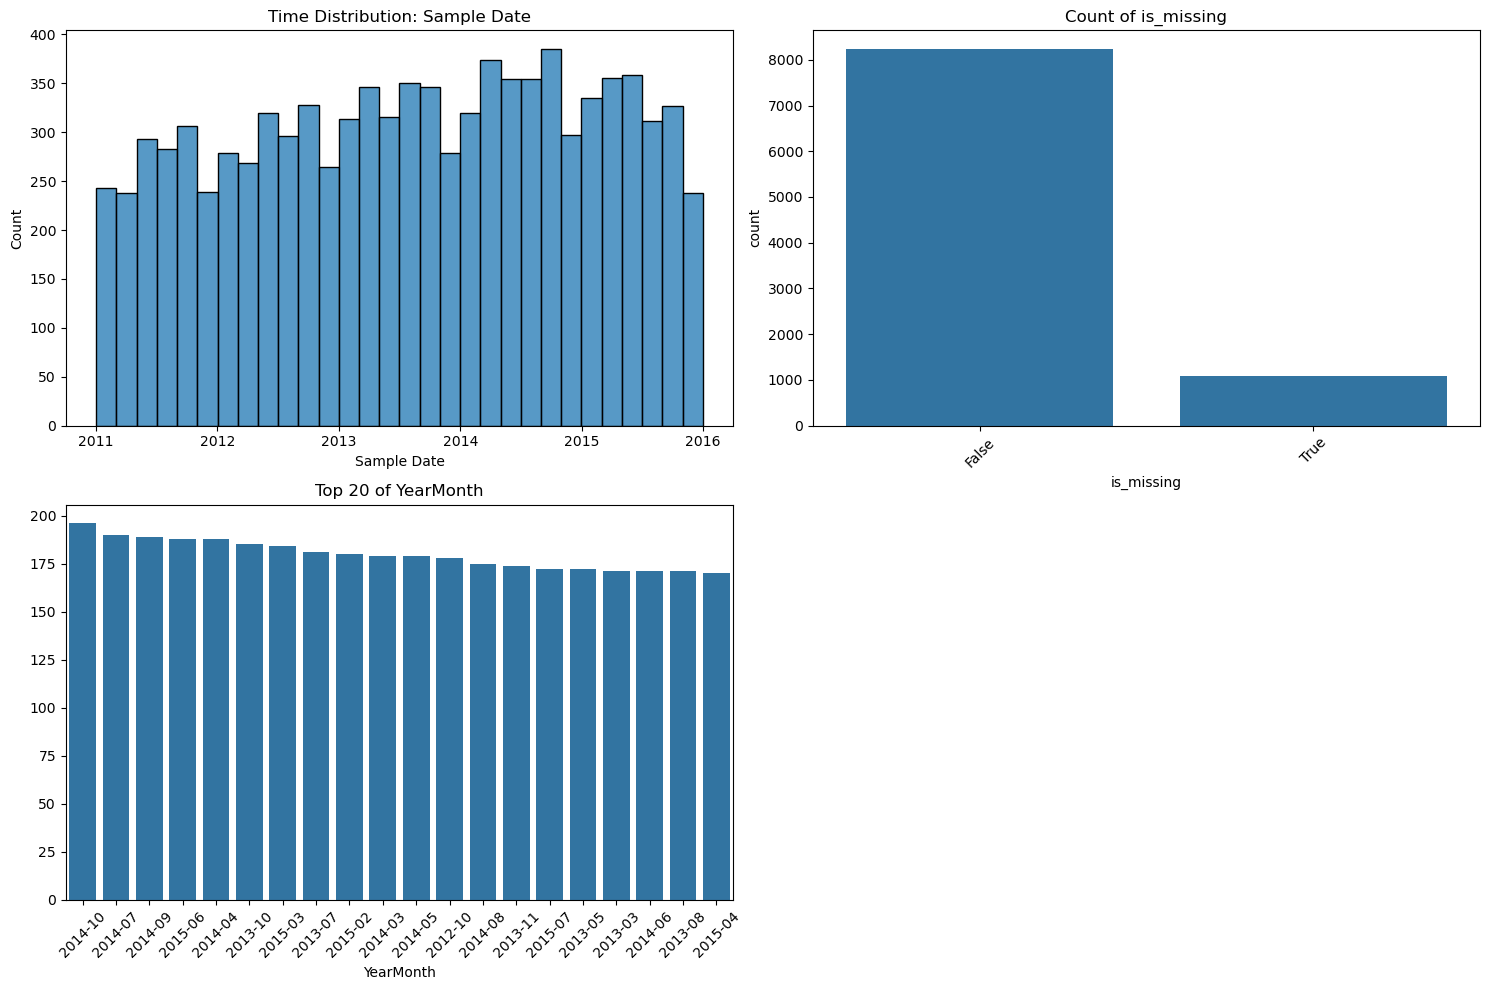

In [30]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 날짜 데이터 강제 변환 (형식이 섞여 있을 수 있으므로 format='mixed' 사용)
# errors='coerce'는 변환 불가능한 값을 NaT(결측치)로 만듭니다.
wq_data['Sample Date'] = pd.to_datetime(wq_data['Sample Date'], dayfirst=True, errors='coerce')

n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 데이터 타입 확인
    is_datetime = pd.api.types.is_datetime64_any_dtype(wq_data[col])
    unique_count = wq_data[col].nunique()

    if is_datetime:
        # 날짜 데이터는 히스토그램으로 분포 확인
        sns.histplot(data=wq_data, x=col, ax=axes[i], bins=30)
        axes[i].set_title(f'Time Distribution: {col}')
    elif unique_count > 30:
        # 범주형인데 고유값이 너무 많으면 상위 20개만 출력 (안 그러면 렉 걸리고 그래프 깨짐)
        top20 = wq_data[col].value_counts().head(20)
        sns.barplot(x=top20.index, y=top20.values, ax=axes[i])
        axes[i].set_title(f'Top 20 of {col}')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        # 일반적인 범주형 데이터
        sns.countplot(x=col, data=wq_data, ax=axes[i])
        axes[i].set_title(f'Count of {col}')
        axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [35]:
pearson_corr = wq_data[num_cols].corr(method='pearson')
pearson_corr

,Latitude,Longitude,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,nir,green,swir16,swir22,NDMI,...,pdsi,q,soil,tmax,tmin,vpd,Month,month,sin_month,cos_month
Latitude,1.000000,0.624468,0.318495,0.115727,0.257010,-0.042791,0.010520,0.121183,0.137749,-0.233496,...,-0.027469,0.119572,-0.013727,0.236068,0.171880,0.109618,-0.012153,-0.012153,0.016705,-0.008895
Longitude,0.624468,1.000000,0.036686,-0.213808,0.022743,0.050125,-0.012702,0.076827,0.060012,-0.057101,...,-0.070565,0.275607,0.322805,-0.217063,0.085295,-0.447335,-0.007635,-0.007635,0.013913,-0.007679
Total Alkalinity,0.318495,0.036686,1.000000,0.692436,0.316777,0.015579,0.061622,0.191913,0.211446,-0.274070,...,-0.120611,-0.094436,-0.270956,0.311748,0.034042,0.337245,0.101933,0.101933,-0.120644,-0.044567
Electrical Conductance,0.115727,-0.213808,0.692436,1.000000,0.279405,0.037289,0.028293,0.144659,0.159797,-0.177506,...,-0.133090,-0.141040,-0.282368,0.299823,0.102945,0.328006,0.098395,0.098395,-0.118905,-0.047755
Dissolved Reactive Phosphorus,0.257010,0.022743,0.316777,0.279405,1.000000,-0.004762,0.008321,0.059861,0.065900,-0.085012,...,-0.148964,-0.048389,-0.177273,0.035861,-0.068053,0.041973,-0.015919,-0.015919,0.046354,0.069421
nir,-0.042791,0.050125,0.015579,0.037289,-0.004762,1.000000,0.562378,0.722686,0.631083,0.141624,...,-0.017420,0.039138,0.087679,-0.134403,-0.014357,-0.196702,-0.045462,-0.045462,0.119055,0.206668
green,0.010520,-0.012702,0.061622,0.028293,0.008321,0.562378,1.000000,0.593462,0.553481,-0.129511,...,0.007103,-0.022615,-0.040304,0.048186,-0.006019,0.052280,0.051684,0.051684,-0.050429,0.046227
swir16,0.121183,0.076827,0.191913,0.144659,0.059861,0.722686,0.593462,1.000000,0.953234,-0.554963,...,-0.090101,-0.008529,-0.017077,0.010287,-0.042238,-0.056461,0.164687,0.164687,-0.161707,0.048244
swir22,0.137749,0.060012,0.211446,0.159797,0.065900,0.631083,0.553481,0.953234,1.000000,-0.633755,...,-0.104863,-0.033806,-0.041176,0.082838,-0.022227,0.020215,0.228571,0.228571,-0.241556,0.029933
NDMI,-0.233496,-0.057101,-0.274070,-0.177506,-0.085012,0.141624,-0.129511,-0.554963,-0.633755,1.000000,...,0.117807,0.059434,0.123476,-0.189842,0.036520,-0.162260,-0.304897,-0.304897,0.397773,0.200893


In [36]:
pearson_target_TA = pearson_corr['Total Alkalinity'].sort_values(ascending=False)
pearson_target = pearson_target_TA.drop('Total Alkalinity')

pearson_target_EC = pearson_corr['Electrical Conductance'].sort_values(ascending=False)
pearson_target = pearson_target_EC.drop('Electrical Conductance')

pearson_target_DRP = pearson_corr['Dissolved Reactive Phosphorus'].sort_values(ascending=False)
pearson_target = pearson_target_DRP.drop('Dissolved Reactive Phosphorus')

In [37]:
spearman_corr = wq_data[num_cols].corr(method="spearman")
spearman_corr

,Latitude,Longitude,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,nir,green,swir16,swir22,NDMI,...,pdsi,q,soil,tmax,tmin,vpd,Month,month,sin_month,cos_month
Latitude,1.000000,0.420131,0.363617,0.238147,0.287834,0.008467,0.092462,0.184582,0.185286,-0.222866,...,-0.052907,0.425702,-0.058239,0.214864,0.159178,0.126268,-0.008971,-0.008971,0.013713,-0.001954
Longitude,0.420131,1.000000,-0.134807,-0.338345,-0.124891,0.080029,-0.069847,0.054597,0.042746,-0.009729,...,-0.063876,0.539558,0.550252,-0.278566,0.108112,-0.548924,-0.002716,-0.002716,0.005733,-0.015516
Total Alkalinity,0.363617,-0.134807,1.000000,0.784205,0.314581,0.007728,0.241347,0.210789,0.235663,-0.266408,...,-0.128046,0.043539,-0.458817,0.341673,0.056965,0.404706,0.093218,0.093218,-0.105894,-0.061464
Electrical Conductance,0.238147,-0.338345,0.784205,1.000000,0.342987,0.031423,0.118924,0.155544,0.164289,-0.165336,...,-0.126009,-0.103361,-0.445654,0.321949,0.152004,0.381311,0.104988,0.104988,-0.115576,-0.066666
Dissolved Reactive Phosphorus,0.287834,-0.124891,0.314581,0.342987,1.000000,0.016488,0.039212,0.058027,0.058130,-0.040616,...,-0.242905,-0.062938,-0.204367,0.131425,-0.052258,0.204190,-0.023026,-0.023026,0.049365,0.044377
nir,0.008467,0.080029,0.007728,0.031423,0.016488,1.000000,0.274343,0.586663,0.458476,0.164466,...,-0.030532,0.020610,0.150230,-0.104242,0.017561,-0.157577,-0.062622,-0.062622,0.137476,0.312322
green,0.092462,-0.069847,0.241347,0.118924,0.039212,0.274343,1.000000,0.584563,0.626819,-0.430354,...,-0.019862,-0.054301,-0.216761,0.231260,-0.003293,0.250430,0.191734,0.191734,-0.217284,0.128014
swir16,0.184582,0.054597,0.210789,0.155544,0.058027,0.586663,0.584563,1.000000,0.968142,-0.656616,...,-0.121639,0.003888,-0.000690,0.048708,-0.069128,0.013642,0.198605,0.198605,-0.197226,0.042923
swir22,0.185286,0.042746,0.235663,0.164289,0.058130,0.458476,0.626819,0.968142,1.000000,-0.742053,...,-0.135055,-0.028901,-0.036129,0.113872,-0.053848,0.076387,0.259671,0.259671,-0.274218,0.001618
NDMI,-0.222866,-0.009729,-0.266408,-0.165336,-0.040616,0.164466,-0.430354,-0.656616,-0.742053,1.000000,...,0.131611,0.023752,0.144259,-0.171722,0.090769,-0.165989,-0.314570,-0.314570,0.381426,0.245828


In [38]:
spearman_target_TA = spearman_corr['Total Alkalinity'].sort_values(ascending=False)
spearman_target_TA = spearman_target_TA.drop('Total Alkalinity')

spearman_target_EC = spearman_corr['Electrical Conductance'].sort_values(ascending=False)
spearman_target_EC = spearman_target_EC.drop('Electrical Conductance')

spearman_target_DRP = spearman_corr['Dissolved Reactive Phosphorus'].sort_values(ascending=False)
spearman_target_DRP = spearman_target_DRP.drop('Dissolved Reactive Phosphorus')

In [39]:
spearman_target_TA

Electrical Conductance           0.784205
vpd                              0.404706
Latitude                         0.363617
tmax                             0.341673
Dissolved Reactive Phosphorus    0.314581
pet                              0.313451
green                            0.241347
swir22                           0.235663
swir16                           0.210789
def                              0.119918
month                            0.093218
Month                            0.093218
tmin                             0.056965
ppt                              0.044199
q                                0.043539
aet                              0.025875
nir                              0.007728
cos_month                       -0.061464
sin_month                       -0.105894
pdsi                            -0.128046
Longitude                       -0.134807
MNDWI                           -0.152167
NDMI                            -0.266408
soil                            -0